In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [3]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Store"].nunique()
df["Holiday_Flag"].value_counts()
(df["Weekly_Sales"] < 0).sum()
df["Date"].min(), df["Date"].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [7]:
df["Date"].sort_values().diff().value_counts()

Date
0 days    6292
7 days     142
Name: count, dtype: int64

## Findings — Date Range
- Data spans 2010-02-05 to 2012-10-26 (~143 weeks)
- Need to confirm no missing weeks in the sequence

In [8]:
df["Date"].sort_values().diff().value_counts()

Date
0 days    6292
7 days     142
Name: count, dtype: int64

In [9]:
df["Store"].nunique()
df["Store"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [10]:
df["Holiday_Flag"].value_counts()

Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

In [11]:
(df["Weekly_Sales"] < 0).sum()
(df["Weekly_Sales"] == 0).sum()

np.int64(0)

In [12]:
df["Weekly_Sales"].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

In [13]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

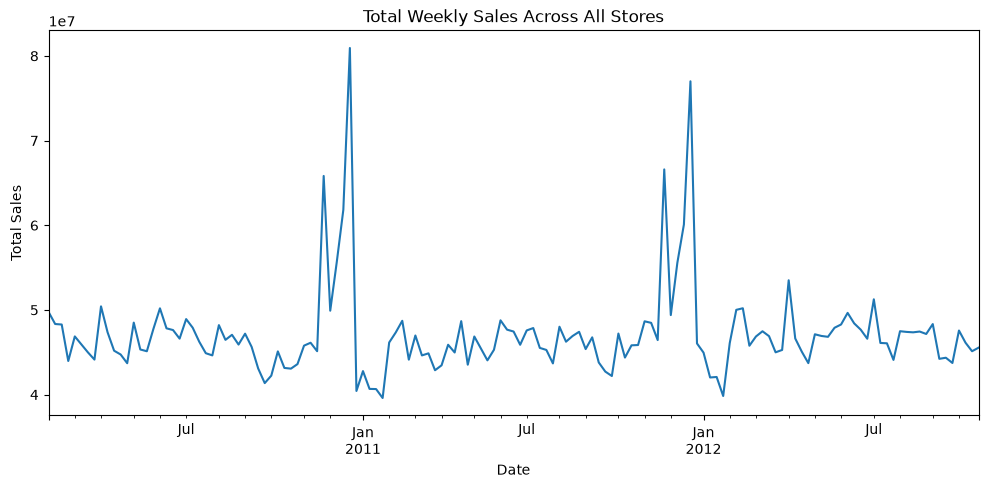

In [15]:
import matplotlib.pyplot as plt

weekly_totals = df.groupby("Date")["Weekly_Sales"].sum()
weekly_totals.plot(figsize=(12,5), title="Total Weekly Sales Across All Stores")
plt.ylabel("Total Sales")
plt.show()

## Findings — Sales Seasonality
- Clear holiday spike each year in late Nov/early Dec, consistent with Thanksgiving/Christmas shopping
- Sharp drop immediately after the holiday peak (early Jan)
- Baseline weekly sales otherwise stable around $45-48M across all stores
- Smaller secondary bump mid-year — worth cross-checking against Holiday_Flag

In [16]:
df[df["Holiday_Flag"] == 1]["Date"].unique()

<DatetimeArray>
['2010-02-12 00:00:00', '2010-09-10 00:00:00', '2010-11-26 00:00:00',
 '2010-12-31 00:00:00', '2011-02-11 00:00:00', '2011-09-09 00:00:00',
 '2011-11-25 00:00:00', '2011-12-30 00:00:00', '2012-02-10 00:00:00',
 '2012-09-07 00:00:00']
Length: 10, dtype: datetime64[us]

## Findings — Holiday Flag Validation
- Holiday_Flag correctly marks: Super Bowl, Labor Day, Thanksgiving, Christmas week
- Confirmed 10 flagged weeks across 2010–2012 matching known US holiday dates
- Explains the two large sales spikes seen in the time series plot (Nov–Dec each year)
- Dataset ends Oct 2012, so 2012 Thanksgiving/Christmas dates aren't included

In [17]:
df.isnull().sum()
df.duplicated().sum()
df["Store"].nunique()
(df["Weekly_Sales"] < 0).sum()

np.int64(0)

In [18]:
df.isnull().sum()
df["Store"].nunique()

45

In [19]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

## EDA Summary — Walmart Sales Dataset
- **Rows:** 6,435 | **Stores:** 45
- **Date range:** 2010-02-05 to 2012-10-26 (weekly data)
- **Nulls:** none found across all columns
- **Duplicates:** 0
- **Negative sales:** 0
- **Holiday_Flag:** correctly marks Super Bowl, Labor Day, Thanksgiving, Christmas weeks
- **Trend:** stable baseline (~$45-48M/week), sharp spikes during Nov-Dec holiday season, dip immediately after New Year